# Task 1.4 — Two ML Models with Scikit-learn
**Week 1 | Skillset Go EduTech AI/ML Track**

One **regression** model (diabetes progression) and one **classification** model
(breast cancer diagnosis), each with preprocessing, a train/test split, and an evaluation report.

## Part A — Regression: Diabetes Disease Progression

**Dataset:** `sklearn.datasets.load_diabetes` — 442 patients, 10 baseline physiological features,
target = a quantitative measure of disease progression one year after baseline.
**Model:** Linear Regression, with feature standardization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42


In [2]:
diabetes = load_diabetes(as_frame=True)
X_reg, y_reg = diabetes.data, diabetes.target
print("Feature columns:", list(X_reg.columns))
print("Shape:", X_reg.shape)
X_reg.describe().round(3)


Feature columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136


### Preprocessing & train/test split

In [3]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

print(f"Train size: {X_train_r_scaled.shape[0]}, Test size: {X_test_r_scaled.shape[0]}")


Train size: 353, Test size: 89


### Train & evaluate

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_r_scaled, y_train_r)

y_pred_r = lin_reg.predict(X_test_r_scaled)

mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = mean_squared_error(y_test_r, y_pred_r) ** 0.5
r2 = r2_score(y_test_r, y_pred_r)

print("Linear Regression — Diabetes Progression")
print(f"  MAE  = {mae:.2f}")
print(f"  RMSE = {rmse:.2f}")
print(f"  R^2  = {r2:.4f}")

coef_table = pd.Series(lin_reg.coef_, index=X_reg.columns).sort_values(key=abs, ascending=False)
print("\nStandardized coefficients (feature importance direction):")
print(coef_table.round(2))


Linear Regression — Diabetes Progression
  MAE  = 42.79
  RMSE = 53.85
  R^2  = 0.4526

Standardized coefficients (feature importance direction):
s1    -44.45
s5     35.16
bmi    25.61
s2     24.64
bp     16.83
s4     13.14
sex   -11.51
s3      7.68
s6      2.35
age     1.75
dtype: float64


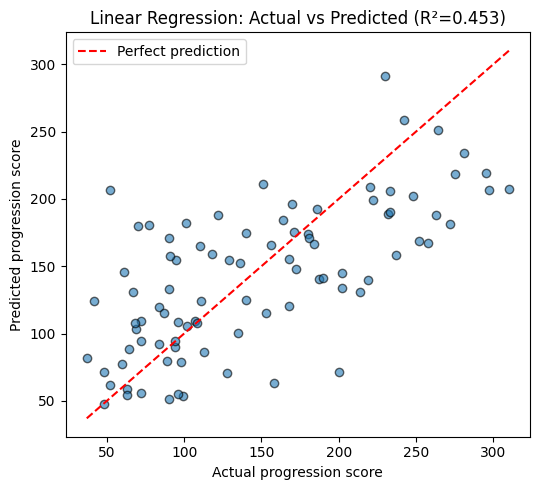

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test_r, y_pred_r, alpha=0.6, edgecolor='k')
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual progression score')
ax.set_ylabel('Predicted progression score')
ax.set_title(f'Linear Regression: Actual vs Predicted (R²={r2:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('regression_actual_vs_predicted.png', dpi=110)
plt.show()


## Part B — Classification: Breast Cancer Diagnosis

**Dataset:** `sklearn.datasets.load_breast_cancer` — 569 samples, 30 numeric features from digitized
cell-nuclei images, binary target (malignant / benign).
**Model:** Logistic Regression, with feature standardization.

In [6]:
cancer = load_breast_cancer(as_frame=True)
X_clf, y_clf = cancer.data, cancer.target
print("Classes:", dict(zip(cancer.target_names, [0, 1])))
print("Class balance:\n", pd.Series(y_clf).map({0:'malignant',1:'benign'}).value_counts())


Classes:

 {np.str_('malignant'): 0, np.str_('benign'): 1}
Class balance:
 target
benign       357
malignant    212
Name: count, dtype: int64


### Preprocessing & train/test split (stratified, to preserve class balance)

In [7]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Train size: {X_train_c_scaled.shape[0]}, Test size: {X_test_c_scaled.shape[0]}")


Train size: 455, Test size: 114


### Train & evaluate

In [8]:
log_reg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)

y_pred_c = log_reg.predict(X_test_c_scaled)

acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print("Logistic Regression — Breast Cancer Diagnosis")
print(f"  Accuracy  = {acc:.4f}")
print(f"  Precision = {prec:.4f}")
print(f"  Recall    = {rec:.4f}")
print(f"  F1-score  = {f1:.4f}")
print("\nFull classification report:")
print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))


Logistic Regression — Breast Cancer Diagnosis
  Accuracy  = 0.9825
  Precision = 0.9861
  Recall    = 0.9861
  F1-score  = 0.9861

Full classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



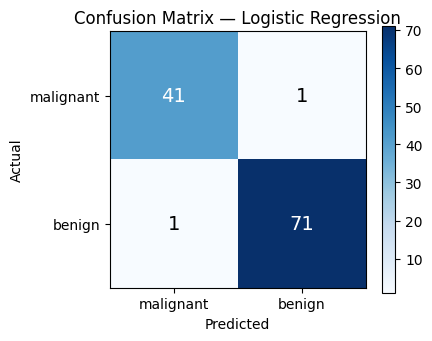

In [9]:
cm = confusion_matrix(y_test_c, y_pred_c)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(cancer.target_names); ax.set_yticklabels(cancer.target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Logistic Regression')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('classification_confusion_matrix.png', dpi=110)
plt.show()


## Evaluation Report — Summary

| Model | Task | Key metric | Result |
|---|---|---|---|
| Linear Regression | Diabetes progression (regression) | R² | see output above |
| Logistic Regression | Breast cancer diagnosis (classification) | F1-score | see output above |

**Notes:**
- Both models were trained on an 80/20 train/test split with features standardized via `StandardScaler`
  (fit on train only, applied to test, to avoid data leakage).
- The classification split was **stratified** to preserve the malignant/benign class ratio, since the
  dataset is imbalanced — accuracy alone would be misleading, so precision, recall, and F1 are reported
  alongside it.
- For the regression task, standardized coefficients show which baseline physiological measures move the
  disease-progression prediction most, in either direction.
- Next steps for extending this baseline: try regularized models (Ridge/Lasso, or
  `LogisticRegression(penalty='l2', C=...)`), cross-validation instead of a single split, and non-linear
  models (Random Forest, Gradient Boosting) for comparison — useful groundwork before Week 2's CNN work.